In [2]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

269.9099099099099
303.78378378378375
213.6936936936937
335.4954954954955
196.036036036036
189.54954954954954


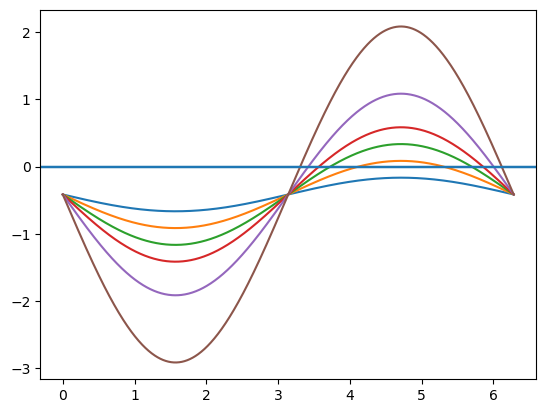

In [3]:
def phi_dot(phi,w1,w2,K):
    return w1 - w2 - K * np.sin(phi)

N = 2
center = 4 * np.pi
spread = 0.5
Kvals = [0.5*spread, spread, 1.5*spread, 2*spread, 3*spread, 5*spread]
w1 = np.random.uniform(center - spread, center + spread)
w2 = np.random.uniform(center - spread, center + spread)

phis = np.linspace(0,2*np.pi,1000)
res = []
for K in Kvals:
    res = []
    for phi in phis:
        res.append(float(phi_dot(phi,w1,w2,K)))
    plt.plot(phis,res)
    min_idx = np.argmin(np.abs(res))
    plt.axhline(y=0)
    print(phis[min_idx]*180 / np.pi)
    


0.0
0.0


Text(0, 0.5, 'rate of change of phase difference')

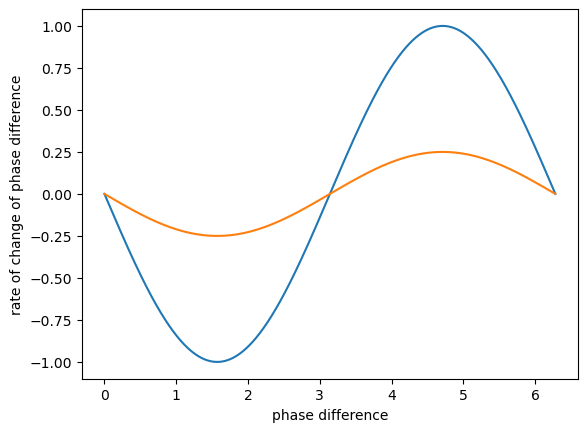

In [4]:
def phi_dot(phi,w1,w2,K):
    return w1 - w2 - K * np.sin(phi)

N = 2
center = 4 * np.pi
spread = 0.5
Kvals = [2*spread,0.5*spread]#[0.5*spread, spread, 1.5*spread, 2*spread, 3*spread, 5*spread]
w1 = np.random.uniform(center - spread, center + spread)
w2 = w1

phis = np.linspace(0,2*np.pi,1000)
res = []
for K in Kvals:
    res = []
    for phi in phis:
        res.append(float(phi_dot(phi,w1,w2,K)))
    plt.plot(phis,res)
    min_idx = np.argmin(np.abs(res))
    print(phis[min_idx]*180 / np.pi)

plt.xlabel('phase difference')
plt.ylabel('rate of change of phase difference')
    

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.472e-01 ...  1.957e+02  2.000e+02]
        y: [[ 3.142e+00  3.210e+00 ...  6.184e+01  6.352e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 350
     njev: 0
      nlu: 0
  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.472e-01 ...  1.879e+02  2.000e+02]
        y: [[ 3.142e+00  3.211e+00 ...  4.076e+01  4.839e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 266
     njev: 0
      nlu: 0
  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.472e-01  1.619e+00  4.134e+00  6.874e+00
             1.012e+01  1.558e+01  2.476e+01  4.107e+01  7.015e+01
             1.230e+02  2.000e+02]
        y: [[ 3.142e+00  3.211e+00  4.196e+00  6.154e+00  6.949e+00
          

Text(0, 0.5, 'phase difference')

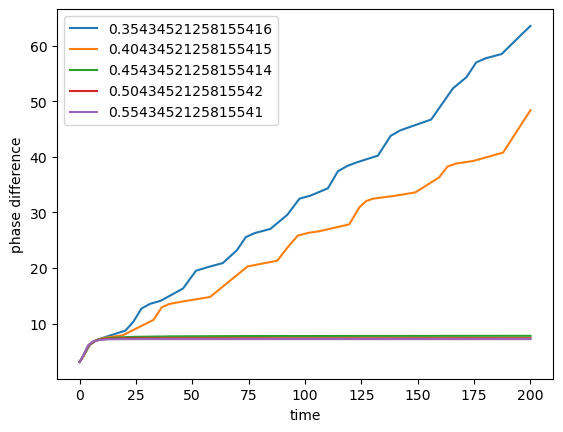

In [22]:

def phi_dot(t,phi,omega,K):
    #return omega - K * np.sin(phi)
    return omega - K*np.sin(phi)

N = 2
center = 4 * np.pi
spread = 0.5
Kvals = [1]
w1 = np.random.uniform(center - spread, center + spread)
w2 = np.random.uniform(center - spread, center + spread)
omega = w2 - w1
critical = abs(omega)

phis = np.linspace(0,2*np.pi,1000)


from scipy.integrate import solve_ivp


Kv = [critical-0.1,critical-0.05, critical, critical+0.05, critical+0.1]
phi_0 = [np.pi]
for K in Kv:
    sol = solve_ivp(phi_dot,[0,200],phi_0,args=(omega,K))
    print(sol)
    plt.plot(sol.t,sol.y[0],label=K)
plt.legend()
plt.xlabel('time')
plt.ylabel('phase difference')

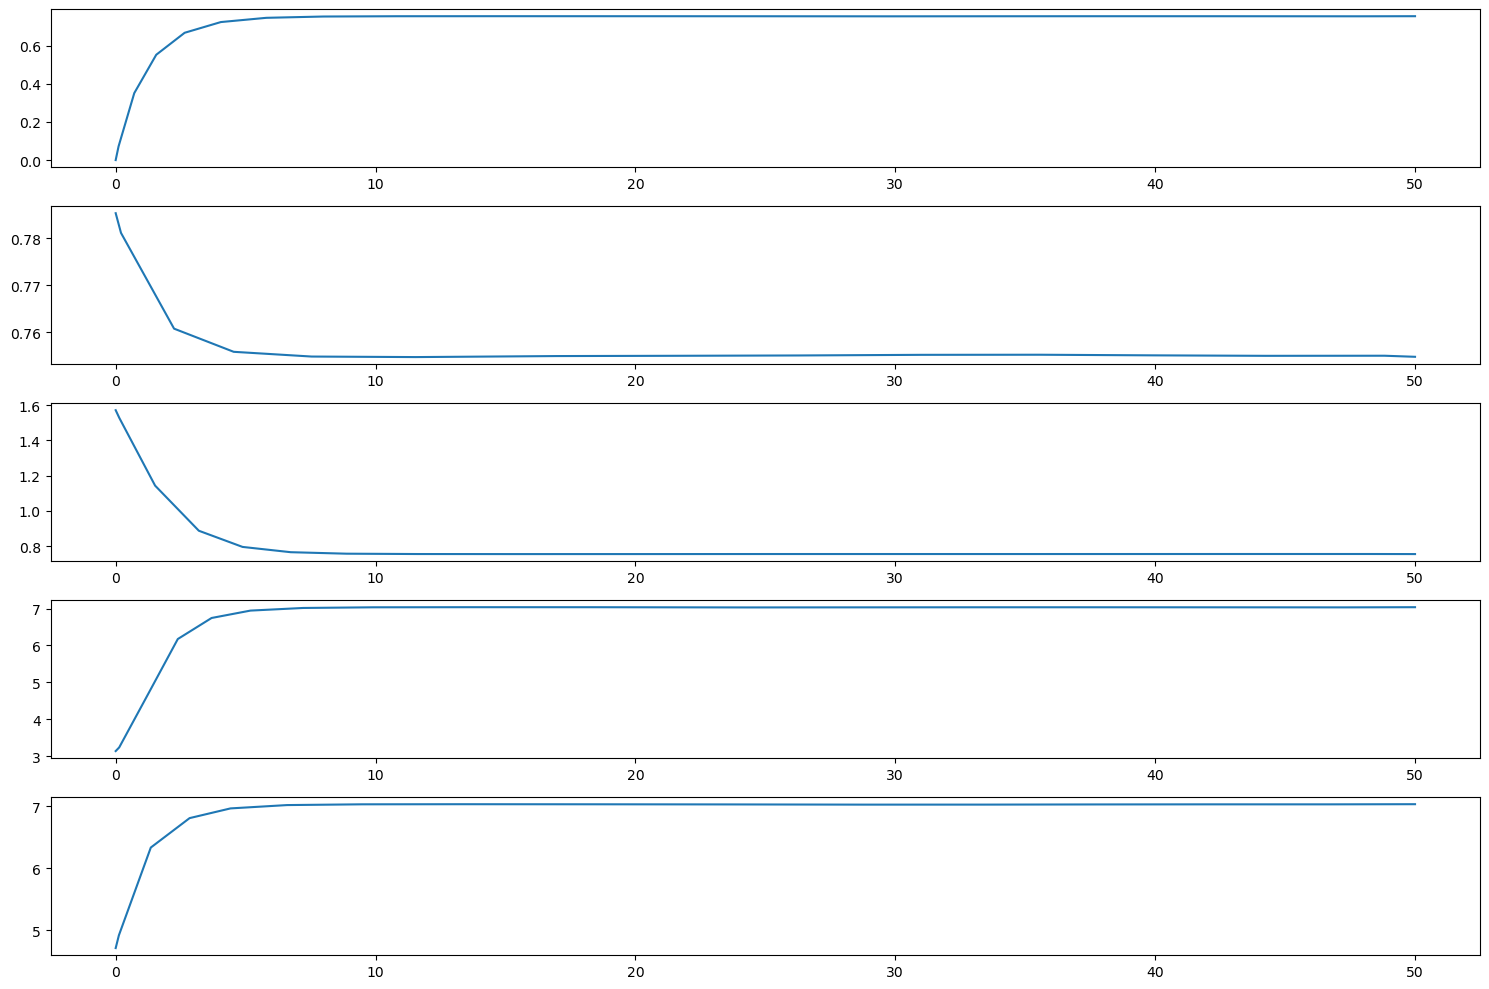

In [6]:
starts = [0, np.pi/4, np.pi/2, np.pi, 3*np.pi/2]
fig,axs = plt.subplots(len(starts),1,figsize=(15,10))
K = 1
for idx,start_condition in enumerate(starts):
    sol = solve_ivp(phi_dot,[0,50],[start_condition],args=(omega,K))
    axs[idx].plot(sol.t,sol.y[0])
plt.tight_layout()


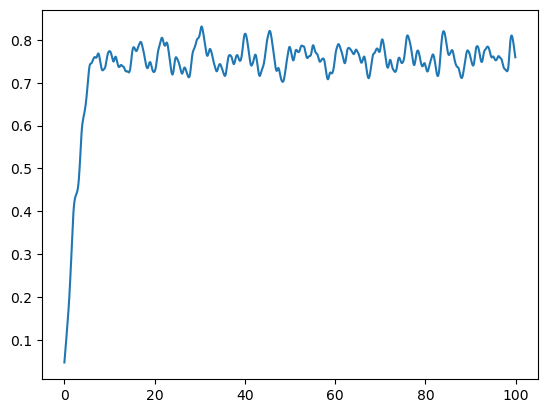

In [20]:
#attempting n to inf case

N = 100

omega = np.random.randn(N)
K = 1.8
theta = np.random.uniform(0,2*np.pi,N)

dt = 0.1
time = np.arange(0,100,dt)

r_history = np.zeros(len(time))
sols = []

for idx,t in enumerate(time):
 
    z = np.mean(np.exp(1j*theta))
    r = np.abs(z)
    psi = np.angle(z)

    r_history[idx] = r

    theta_dot = omega + K*r*np.sin(psi - theta)
    sols.append(theta_dot)
    theta += theta_dot * dt

plt.plot(time,r_history)